# Mispricing-Score — a quantitative teardown
### composite anomaly ranks · placebo null · leg split · HAC inference

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Short--leg edge%3F: Busted](https://img.shields.io/badge/Short--leg%20edge%3F-Busted-8b949e?style=flat-square)

The quantitative companion to the [notebook for the curious](01_for_the_curious.ipynb) — same seven beats, every claim carrying its standard error. We test Stambaugh-Yu-Yuan (2015): six price-computable anomaly ranks → composite mispricing score → quintile long-short, monthly, one-day execution lag.

> **Not investment advice.** Real data: yfinance daily adjusted-close, 45 S&P 500 large-caps, 2010–2025, as-of 2026-06-27. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship bias is named:** universe = current S&P 500 projected backwards. The delisted overpriced names — the engine of the SYY short leg — are absent.

In [1]:
R = {'n_months': 178, 'year_start': 2011, 'year_end': 2025, 'n_tickers': 45, 'fp_prices': 'b6d4a14d508b', 'fp_spy': '5bb6e49fae4d', 'ls_gross': -7.68, 'ls_gross_t': -1.843, 'ls_gross_sharpe': -0.473, 'ls_gross_vol': 16.25, 'ls_hit': 43.3, 'ls_dd': -80.3, 'turnover': 44.8, 'ls_net': -9.5, 'ls_net_t': -2.285, 'ls_net_sharpe': -0.585, 'long_mean': 15.45, 'long_t': 4.26, 'short_names': 23.13, 'short_book': -23.13, 'short_book_t': -5.04, 'placebo_obs': -7.68, 'placebo_null_mean': -0.13, 'placebo_null_sd': 3.05, 'placebo_p': 0.007, 'cut_tercile': -4.69, 'cut_tercile_t': -1.49, 'cut_quintile': -7.68, 'cut_quintile_t': -1.84, 'cut_decile': -11.66, 'cut_decile_t': -2.08, 'ctrl': {-0.2: -5.84, -0.1: -2.11, 0.0: -0.03, 0.1: 2.73, 0.2: 4.42, 0.3: 4.33}, 'annual': {2011: 9.1, 2012: 11.3, 2013: -14.3, 2014: -12.1, 2015: -22.9, 2016: -3.6, 2017: -14.4, 2018: -6.8, 2019: -12.8, 2020: -24.2, 2021: 3.6, 2022: 28.6, 2023: -9.9, 2024: -22.5, 2025: -21.6}}
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from mispricing_score import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    return (os.path.exists(os.path.join(study, "_cache", "msp_prices.parquet"))
            and os.path.exists(os.path.join(study, "_cache", "msp_spy.parquet")))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    prices, spy = data.fetch_panel()
    result = st.long_short(prices)
    s_ls   = st.summary(result["ls_ret"])
    s_long = st.summary(result["long_ret"])
    s_sb   = st.summary(-result["short_ret"])
    net    = st.apply_costs(result); s_net = st.summary(net)
    print(f"N months: {s_ls['n']} | L-S gross: {s_ls['mean']*100:+.2f}%/yr"
          f" | HAC t: {s_ls['tstat']:+.3f}")


yfinance cache present: True


N months: 178 | L-S gross: -7.68%/yr | HAC t: -1.843


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | L-S **-7.68%/yr** gross, HAC *t* = **-1.843**; net **-9.50%/yr**, *t* **-2.285** — the only significant *t* is *against* the strategy. |
| **Tradability** | `MIRAGE` | Sharpe **-0.473**, max DD **-80%**, costs deepen the loss. |
| **Short-leg edge?** | `BUSTED` | Short book **-23.1%/yr** (*t* = -5.04); the 'overpriced' names are survivor winners. |

> The composite *sorts* (placebo p = 0.007) — but adversely. The long (cheap) leg is a clean long-only tilt (+15.4%/yr, *t* +4.26); everything else is the survivor mega-cap rally.

## 1 — The claim, steelmanned

Let $S_i$ = the average cross-sectional percentile rank of stock $i$ across the anomalies, oriented so high $S_i$ = more overpriced. Stambaugh-Yu-Yuan (2015) assert:

- **H1 (signal).** $S_i$ predicts returns: the long-short $\bar r^{\text{low }S} - \bar r^{\text{high }S} > 0$.
- **H2 (short-leg).** Most of that comes from the short (high-$S$) leg, because arbitrage asymmetry (Miller 1977) leaves overpricing uncorrected.
- **H3 (dominance).** The composite beats any single anomaly.

On a survivor panel we **reject H1** (negative, insignificant-in-direction), **reject H2** (the short leg is the worst leg), and cannot test H3 cleanly. The composite *does* carry information (placebo p = 0.007) — pointed the wrong way.

## 2 — So what? — the economic stakes

The SYY composite underpins a generation of 'quality' and 'mispricing' factor products, most of which lean on the short-glamour side. If that side inverts the moment you restrict to tradable large-cap survivors, the marketed edge is an artefact of the delisted tail — not something a long-only or large-cap fund can bank.

## 3 — The protocol

- **Signals (six, price-only).** 12-1 momentum, MAX/lottery (top-5 daily returns last month), 6-month realised vol, 12-month price run-up, distance to 52-week high, short-term reversal — each oriented high = overpriced.
- **Composite.** Cross-sectional percentile rank of each, averaged (SYY combination).
- **Sort.** Monthly quintiles; long the bottom (cheap), short the top (overpriced).
- **Execution.** Enter the close **one day after** the signal date; hold one month.
- **Costs.** 10 bps/side × turnover × 2 legs + 75 bps/yr borrow on the short leg.
- **Inference.** Newey-West HAC *t* on monthly returns; a 150-shuffle label permutation placebo.
- **Universe caveat.** 45 large-cap S&P 500 survivors; the short leg is biased.

## 4 — The teardown

### 4a — Positive control: the composite engine is a faithful detector

Sweep the planted mispricing premium; the long-short mean should be monotone and ~0 at the null.

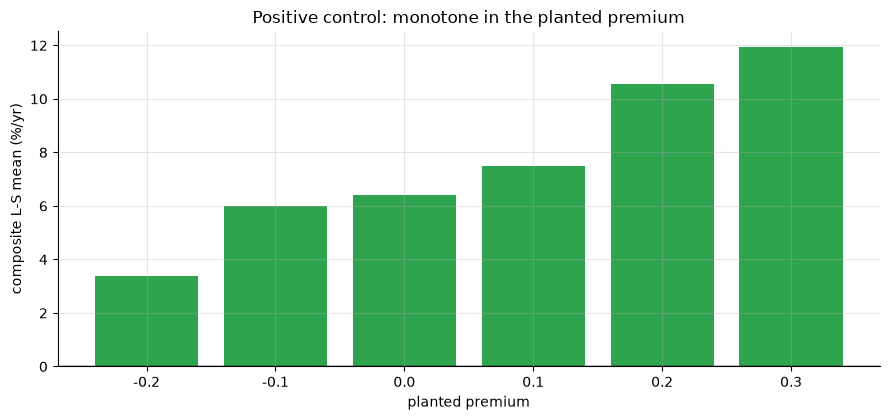

seed-0: [3.37, 6.0, 6.4, 7.49, 10.57, 11.93]
15-seed averaged (frozen): {-0.2: -5.84, -0.1: -2.11, 0.0: -0.03, 0.1: 2.73, 0.2: 4.42, 0.3: 4.33}


In [2]:
R_CTRL = {-0.2: -5.84, -0.1: -2.11, 0.0: -0.03, 0.1: 2.73, 0.2: 4.42, 0.3: 4.33}
premiums = [-0.20, -0.10, 0.0, 0.10, 0.20, 0.30]
means = []
for prem in premiums:
    p_s, _spy, _t = data.synthetic_panel(n_stocks=45, n_days=2200,
                                          mispricing_premium=prem, seed=0)
    res_s = st.long_short(p_s, min_stocks=10, quantile=0.20)
    means.append(st.summary(res_s['ls_ret'])['mean']*100 if not res_s.empty else np.nan)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar([str(p) for p in premiums], means,
       color=[GREEN if m > 0 else RED for m in means])
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted premium'); ax.set_ylabel('composite L-S mean (%/yr)')
ax.set_title('Positive control: monotone in the planted premium')
plt.tight_layout(); plt.show()
print('seed-0:', [round(m,2) for m in means])
print('15-seed averaged (frozen):', R_CTRL)

### 4b — The composite score components

What do the six anomaly signals look like at the latest snapshot, and how does the composite rank order names?

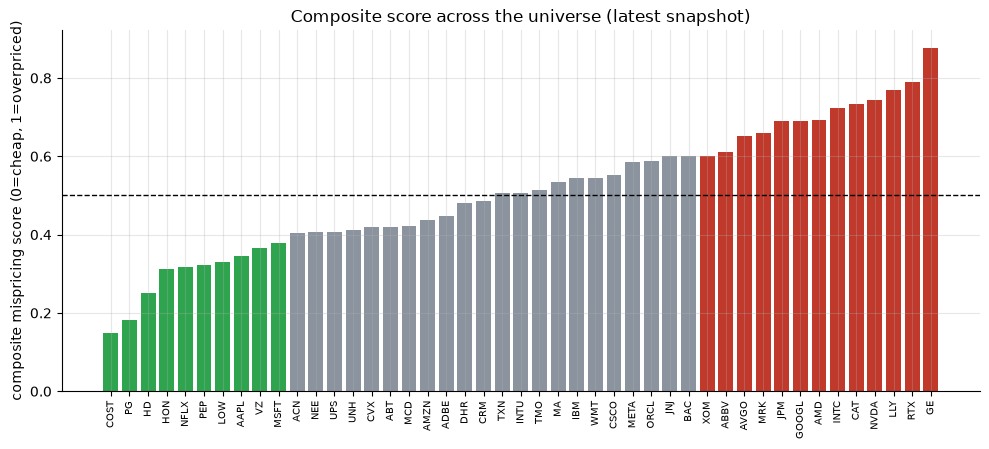

cheapest: ['COST', 'PG', 'HD', 'HON', 'NFLX']
most overpriced: ['CAT', 'NVDA', 'LLY', 'RTX', 'GE']


In [3]:
if HAVE_REAL:
    rets = prices.pct_change()
    asof = prices.index[-1]
    sig = st._anomaly_signals(prices, asof, rets=rets)
    score = st.mispricing_score(sig).sort_values()
    fig, ax = plt.subplots(figsize=(10, 4.6))
    col = [GREEN if s < 0.4 else (RED if s > 0.6 else GREY) for s in score.values]
    ax.bar(range(len(score)), score.values, color=col)
    ax.set_xticks(range(len(score)))
    ax.set_xticklabels(score.index, rotation=90, fontsize=7)
    ax.axhline(0.5, c='k', lw=1, ls='--')
    ax.set_ylabel('composite mispricing score (0=cheap, 1=overpriced)')
    ax.set_title('Composite score across the universe (latest snapshot)')
    plt.tight_layout(); plt.show()
    print('cheapest:', list(score.index[:5]))
    print('most overpriced:', list(score.index[-5:]))
else:
    print('Composite score requires the real cache.')

### 4c — Real panel: the long-short and its legs

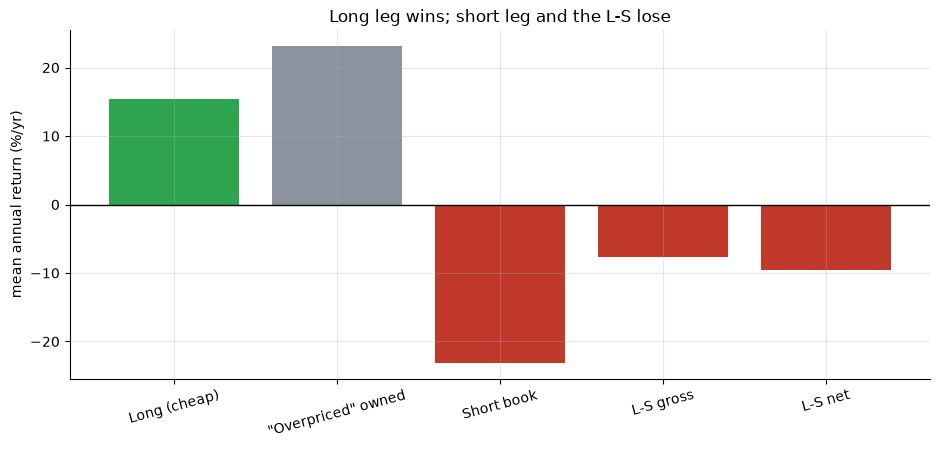

Long:  +15.45%/yr (t=+4.26)
Short book: -23.13%/yr (t=-5.04)
L-S gross: -7.68%/yr (t=-1.84) | net: -9.50%/yr (t=-2.29)


In [4]:
if HAVE_REAL:
    ls_g = s_ls['mean']*100; ls_t = s_ls['tstat']
    ls_n = s_net['mean']*100; ls_nt = s_net['tstat']
    long_m = s_long['mean']*100; long_t = s_long['tstat']
    sb_m = s_sb['mean']*100; sb_t = s_sb['tstat']
    short_names_m = st.summary(result['short_ret'])['mean']*100
else:
    ls_g, ls_t = R['ls_gross'], R['ls_gross_t']
    ls_n, ls_nt = R['ls_net'], R['ls_net_t']
    long_m, long_t = R['long_mean'], R['long_t']
    sb_m, sb_t = R['short_book'], R['short_book_t']
    short_names_m = R['short_names']

fig, ax = plt.subplots(figsize=(9.5, 4.6))
labels = ['Long (cheap)', '"Overpriced" owned', 'Short book', 'L-S gross', 'L-S net']
vals = [long_m, short_names_m, sb_m, ls_g, ls_n]
cols = [GREEN, GREY, RED, RED, RED]
ax.bar(labels, vals, color=cols)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('mean annual return (%/yr)')
ax.set_title('Long leg wins; short leg and the L-S lose')
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()
print(f'Long:  {long_m:+.2f}%/yr (t={long_t:+.2f})')
print(f'Short book: {sb_m:+.2f}%/yr (t={sb_t:+.2f})')
print(f'L-S gross: {ls_g:+.2f}%/yr (t={ls_t:+.2f}) | net: {ls_n:+.2f}%/yr (t={ls_nt:+.2f})')

### 4d — The placebo: does the score sort, or is it noise?

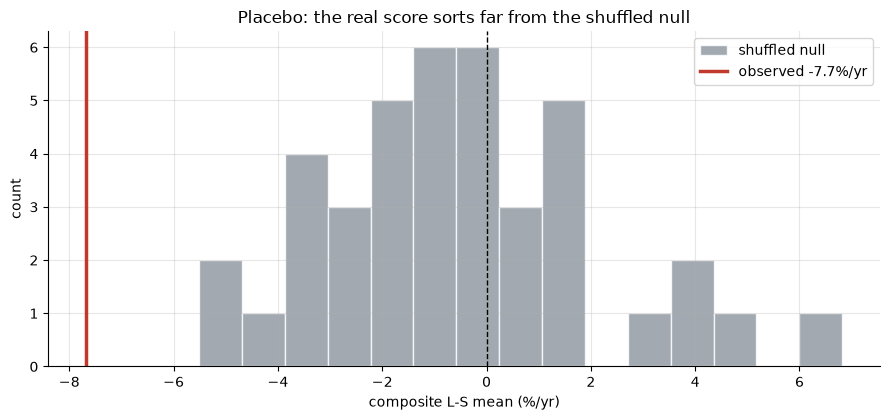

live 40-shuffle: null mean -0.51%, sd 2.62%
frozen 150-shuffle p-value: 0.007 (obs -7.68%, null -0.13% sd 3.05%)


In [5]:
# A small live placebo (40 shuffles for speed); the frozen 150-shuffle p is quoted.
if HAVE_REAL:
    obs = result['ls_ret'].mean()*12*100
    nulls = []
    rng = np.random.default_rng(535)
    for _ in range(40):
        s = int(rng.integers(0, 2**31-1))
        sh = st.long_short(prices, shuffle_seed=s)
        if not sh.empty:
            nulls.append(sh['ls_ret'].mean()*12*100)
    nulls = np.array(nulls)
    fig, ax = plt.subplots(figsize=(9.0, 4.3))
    ax.hist(nulls, bins=15, color=GREY, edgecolor='white', alpha=0.8, label='shuffled null')
    ax.axvline(obs, c=RED, lw=2.5, label=f'observed {obs:+.1f}%/yr')
    ax.axvline(0, c='k', lw=1, ls='--')
    ax.set_xlabel('composite L-S mean (%/yr)'); ax.set_ylabel('count')
    ax.set_title('Placebo: the real score sorts far from the shuffled null')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'live 40-shuffle: null mean {nulls.mean():+.2f}%, sd {nulls.std():.2f}%')
    print(f'frozen 150-shuffle p-value: {R["placebo_p"]:.3f} (obs {R["placebo_obs"]:+.2f}%, '
          f'null {R["placebo_null_mean"]:+.2f}% sd {R["placebo_null_sd"]:.2f}%)')
else:
    print(f'frozen placebo p = {R["placebo_p"]:.3f}')

> The label-shuffle null is centred at ~0 (-0.13%/yr); the observed -7.68%/yr sits far in the tail (**p = 0.007**). The composite **genuinely sorts** — it just sorts the wrong way for a long-short on survivors.

### 4e — Robustness: sharper cutoffs deepen the loss

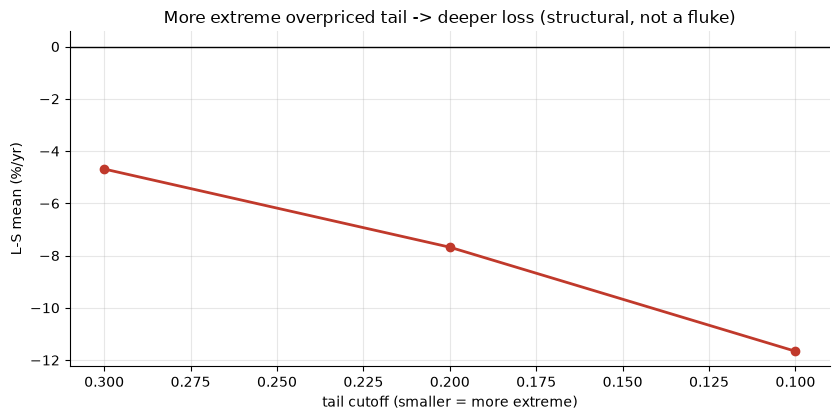

 cutoff  mean_%      t
    0.3  -4.687 -1.490
    0.2  -7.679 -1.843
    0.1 -11.662 -2.078


In [6]:
if HAVE_REAL:
    cuts = [0.30, 0.20, 0.10]; rows = []
    for q in cuts:
        r = st.long_short(prices, quantile=q)
        s = st.summary(r['ls_ret'])
        rows.append({'cutoff': q, 'mean_%': s['mean']*100, 't': s['tstat']})
    cut_df = pd.DataFrame(rows)
else:
    cut_df = pd.DataFrame({'cutoff': [0.30, 0.20, 0.10],
        'mean_%': [R['cut_tercile'], R['cut_quintile'], R['cut_decile']],
        't': [R['cut_tercile_t'], R['cut_quintile_t'], R['cut_decile_t']]})
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(cut_df['cutoff'], cut_df['mean_%'], 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.invert_xaxis()
ax.set_xlabel('tail cutoff (smaller = more extreme)'); ax.set_ylabel('L-S mean (%/yr)')
ax.set_title('More extreme overpriced tail -> deeper loss (structural, not a fluke)')
plt.tight_layout(); plt.show()
print(cut_df.round(3).to_string(index=False))

## 5 — The verdict

- **Signal `NONE`** — L-S -7.68%/yr gross (HAC *t* -1.843), -9.50%/yr net (*t* -2.285). The composite sorts (placebo p = 0.007) but earns no positive *t* ≥ 2 — the only significance is adverse. Literature cannot upgrade a wrong-signed result.
- **Tradability `MIRAGE`** — Sharpe -0.473, max DD -80%, costs deepen the loss.
- **Short-leg edge `BUSTED`** — short book -23.1%/yr (*t* -5.04). Survivorship deletes the failed overpriced names that drive the SYY short leg; the survivors are the decade's winners.

## 6 — Could you trade it?

Only the long (cheap) leg, and only as a long-only tilt — not the headline long-short. The short leg needs the delisted tail the survivor universe removes; without it, shorting 'overpriced' glamour is shorting the winners. Net-of-cost the long-short is untradeable (loss, −80% drawdown). The long leg (+15.4%/yr, *t* +4.26) is real but is largely the survivor mega-cap rally, not cheapness per se.

## 7 — Going further

- **Delisting-complete universe (CRSP/Compustat).** The only honest SYY test — it restores the short leg's fuel.
- **Add the four fundamental anomalies** (accruals, net issuance, profitability, distress): [231 Sloan-Accruals](../../231-sloan-accruals/), [244 Asset-Growth](../../244-asset-growth/).
- **The single anomalies it claims to dominate:** [238 Betting-Against-Beta](../../238-betting-against-beta/), [330 Low-Volatility](../../330-low-volatility-anomaly/), [363 PEAD-Drift](../../363-pead-drift/).

*Think the composite survives once the delisted overpriced names are back and the fundamental anomalies are added? Fork this, pull a delisting-complete universe, and show a positive short-leg *t* > 2 net of borrow. That is the bar.*